In [ ]:
# =========================================
# 1) SETUP
# =========================================
!pip -q install --upgrade google-cloud-bigquery pandas pyarrow scikit-learn matplotlib

from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

client = bigquery.Client(project="adroit-sol-489009-e3")
print("Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 97.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 wh

In [ ]:
# =========================================
# 2) DATA EXTRACTION
# =========================================
query = """
SELECT
  timestamp AS block_timestamp,
  transaction_count,
  size,
  weight
FROM `bigquery-public-data.crypto_bitcoin.blocks`
WHERE timestamp >= TIMESTAMP('2020-01-01')
  AND timestamp < TIMESTAMP('2021-01-01')
ORDER BY block_timestamp
"""

df = client.query(query).to_dataframe()
print("Rows fetched:", len(df))
display(df.head())
print(df.columns)

Rows fetched: 53222


,block_timestamp,transaction_count,size,weight
0,2020-01-01 00:03:05+00:00,2500,1250129,3993629
1,2020-01-01 00:07:32+00:00,1840,661706,1934741
2,2020-01-01 00:13:34+00:00,1105,436344,1289973
3,2020-01-01 00:19:00+00:00,982,467181,1324209
4,2020-01-01 00:37:32+00:00,2881,1123752,3399753


Index(['block_timestamp', 'transaction_count', 'size', 'weight'], dtype='str')


In [ ]:
# =========================================
# 3) FEATURE ENGINEERING
# =========================================
df = df.copy()
df["block_timestamp"] = pd.to_datetime(df["block_timestamp"])
df = df.sort_values("block_timestamp").reset_index(drop=True)

# target = time between consecutive blocks
df["prev_block_timestamp"] = df["block_timestamp"].shift(1)
df["block_time"] = (df["block_timestamp"] - df["prev_block_timestamp"]).dt.total_seconds()

# basic temporal features
df["hour"] = df["block_timestamp"].dt.hour
df["dayofweek"] = df["block_timestamp"].dt.dayofweek

# rolling workload descriptors
df["tx_ma_5"] = df["transaction_count"].rolling(5).mean()
df["tx_std_5"] = df["transaction_count"].rolling(5).std()

df["size_ma_5"] = df["size"].rolling(5).mean()
df["weight_ma_5"] = df["weight"].rolling(5).mean()

df["prev_block_time"] = df["block_time"].shift(1)
df["prev_block_time_ma_3"] = df["block_time"].shift(1).rolling(3).mean()
df["prev_block_time_std_3"] = df["block_time"].shift(1).rolling(3).std()

# burst / queue proxies
global_tx_mean = df["transaction_count"].mean()
global_tx_std = df["transaction_count"].std()

df["burst_flag"] = (df["transaction_count"] > (global_tx_mean + global_tx_std)).astype(int)

df["queue_pressure"] = (
    0.5 * (df["transaction_count"] / df["transaction_count"].max()) +
    0.5 * (df["weight"] / df["weight"].max())
)

df["tx_pct_change"] = df["transaction_count"].pct_change().replace([np.inf, -np.inf], np.nan)
df["weight_pct_change"] = df["weight"].pct_change().replace([np.inf, -np.inf], np.nan)

# drop missing rows from rolling/shift
df = df.dropna().reset_index(drop=True)

feature_cols = [
    "transaction_count",
    "size",
    "weight",
    "hour",
    "dayofweek",
    "tx_ma_5",
    "tx_std_5",
    "size_ma_5",
    "weight_ma_5",
    "prev_block_time",
    "prev_block_time_ma_3",
    "prev_block_time_std_3",
    "burst_flag",
    "queue_pressure",
    "tx_pct_change",
    "weight_pct_change",
]

target_col = "block_time"

print("Feature count:", len(feature_cols))
display(df[feature_cols + [target_col]].head())

Feature count: 16


,transaction_count,size,weight,hour,dayofweek,tx_ma_5,tx_std_5,size_ma_5,weight_ma_5,prev_block_time,prev_block_time_ma_3,prev_block_time_std_3,burst_flag,queue_pressure,tx_pct_change,weight_pct_change,block_time
0,2881,1123752,3399753,0,2,1861.6,835.663987,787822.4,2388461.0,326.0,318.333333,47.961790,0,0.754111,1.933809,1.567384,1112.0
1,1,366,1464,0,2,1361.8,1072.219054,537869.8,1590028.0,1112.0,600.000000,443.770211,0,0.000297,-0.999653,-0.999569,36.0
2,462,190998,598089,0,2,1086.2,1095.422613,443728.2,1322697.6,36.0,491.333333,556.727342,0,0.127543,461.0,407.530738,123.0
3,825,351340,1040683,0,2,1030.2,1101.362202,426727.4,1272839.6,123.0,423.666667,597.699200,0,0.224339,0.785714,0.740014,251.0
4,1341,455740,1371097,0,2,1102.0,1109.109102,424439.2,1282217.2,251.0,136.666667,108.149588,0,0.324588,0.625455,0.317497,454.0


In [ ]:
# =========================================
# 4) TRAIN / TEST SPLIT
# =========================================
X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (42574, 16) Test: (10644, 16)


In [ ]:
# =========================================
# 5) MODEL TRAINING
# =========================================
models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    ),
    "MLP": MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        learning_rate_init=0.0008,
        max_iter=700,
        early_stopping=True,
        random_state=42
    )
}

results = []
pred_store = {}

for name, model in models.items():
    if name == "MLP":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    pred_store[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)

,Model,MAE,RMSE,R2
0,MLP,314.483708,482.746476,0.376130
1,RandomForest,314.925939,483.877513,0.373203
2,GradientBoosting,325.837725,493.585897,0.347799


,Feature,Importance
1,size,0.245505
13,queue_pressure,0.233640
0,transaction_count,0.102325
14,tx_pct_change,0.075863
15,weight_pct_change,0.055610
3,hour,0.045924
9,prev_block_time,0.040017
5,tx_ma_5,0.034149
10,prev_block_time_ma_3,0.033415
2,weight,0.029889


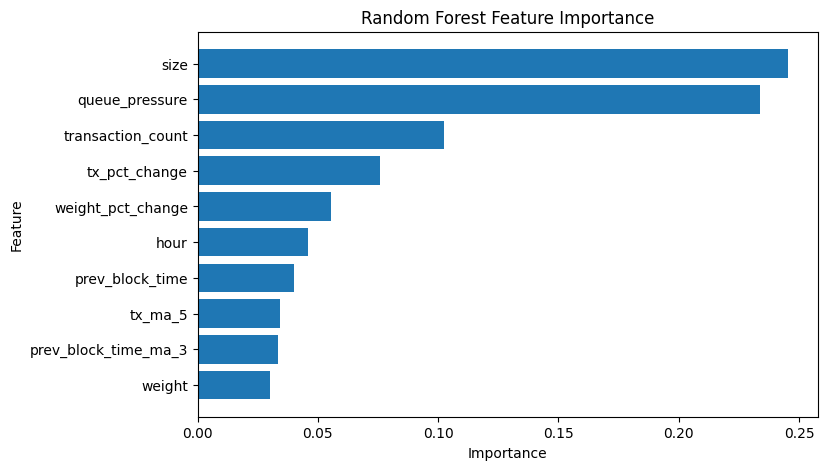

In [ ]:
# =========================================
# 6) FEATURE IMPORTANCE (RF)
# =========================================
rf_model = models["RandomForest"]

feat_imp = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feat_imp.head(10))

plt.figure(figsize=(8, 5))
plt.barh(feat_imp["Feature"].head(10)[::-1], feat_imp["Importance"].head(10)[::-1])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Best model: MLP
          residuals
count  10644.000000
mean      19.541322
std      482.373462
min    -1732.020155
25%     -243.587183
50%      -41.719044
75%      158.026735
max     5105.132067


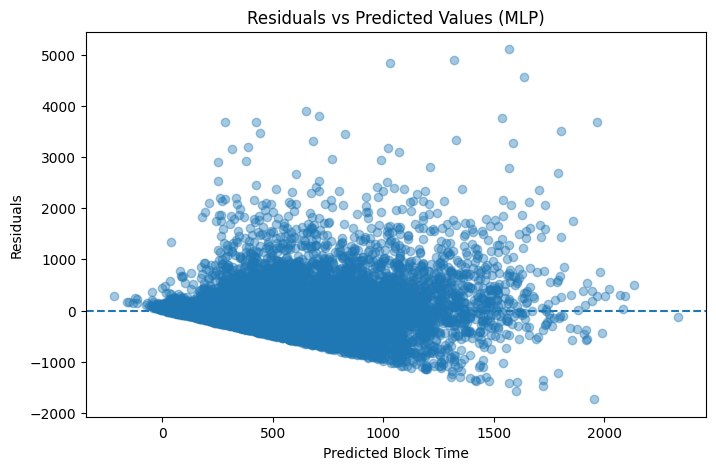

In [ ]:
# =========================================
# 7) RESIDUAL ANALYSIS
# =========================================
best_model_name = results_df.iloc[0]["Model"]
best_preds = pred_store[best_model_name]

residuals = y_test.values - best_preds

print("Best model:", best_model_name)
print(pd.DataFrame(residuals, columns=["residuals"]).describe())

plt.figure(figsize=(8, 5))
plt.scatter(best_preds, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.title(f"Residuals vs Predicted Values ({best_model_name})")
plt.xlabel("Predicted Block Time")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# =========================================
# 8) ADAPTIVE EXECUTION POLICY
# =========================================
target_block_time = 600.0

eval_df = X_test.copy().reset_index(drop=True)
eval_df["actual_block_time"] = y_test.reset_index(drop=True)
eval_df["pred_block_time"] = best_preds

def policy_from_prediction(pred_time):
    if pred_time > 700:
        return pd.Series(["LOW_BATCH", "HIGH_PRIORITY", "OFFCHAIN_BIASED"])
    elif pred_time < 500:
        return pd.Series(["HIGH_BATCH", "NORMAL_PRIORITY", "ONCHAIN_OK"])
    else:
        return pd.Series(["MEDIUM_BATCH", "BALANCED_PRIORITY", "HYBRID"])

eval_df[["batch_level", "priority_mode", "storage_mode"]] = eval_df["pred_block_time"].apply(policy_from_prediction)
display(eval_df.head())

,transaction_count,size,weight,hour,dayofweek,tx_ma_5,tx_std_5,size_ma_5,weight_ma_5,prev_block_time,...,prev_block_time_std_3,burst_flag,queue_pressure,tx_pct_change,weight_pct_change,actual_block_time,pred_block_time,batch_level,priority_mode,storage_mode
0,714,301685,942098,4,6,1113.4,683.044142,843071.8,2268518.2,327.0,...,230.774782,0,0.199335,-0.059289,-0.529028,322.0,231.525540,HIGH_BATCH,NORMAL_PRIORITY,ONCHAIN_OK
1,994,693361,2214835,4,6,976.4,605.538025,664333.2,1912810.8,322.0,...,171.202609,0,0.390425,0.392157,1.35096,390.0,328.536038,HIGH_BATCH,NORMAL_PRIORITY,ONCHAIN_OK
2,1402,805084,2524552,4,6,857.6,366.636468,525159.2,1619044.4,390.0,...,37.898989,0,0.47575,0.410463,0.139838,580.0,557.519019,MEDIUM_BATCH,BALANCED_PRIORITY,HYBRID
3,2962,1375029,3998460,5,6,1366.2,932.798049,772034.8,2336054.8,580.0,...,133.721103,1,0.838208,1.112696,0.58383,2283.0,1906.292616,LOW_BATCH,HIGH_PRIORITY,OFFCHAIN_BIASED
4,2513,1266163,3993178,5,6,1717.0,976.166482,888264.4,2734624.6,2283.0,...,1042.413705,0,0.786257,-0.151587,-0.001321,475.0,615.470921,MEDIUM_BATCH,BALANCED_PRIORITY,HYBRID


In [ ]:
# =========================================
# 9) SIMULATED CONTROLLED BLOCK TIME
# =========================================
def controlled_time(row):
    t = row["pred_block_time"]

    # simple policy effects
    if row["batch_level"] == "LOW_BATCH":
        t = t * 0.90
    elif row["batch_level"] == "HIGH_BATCH":
        t = t * 1.05

    if row["priority_mode"] == "HIGH_PRIORITY":
        t = t * 0.95

    if row["storage_mode"] == "OFFCHAIN_BIASED":
        t = t * 0.93
    elif row["storage_mode"] == "HYBRID":
        t = t * 0.97

    return t

eval_df["controlled_block_time"] = eval_df.apply(controlled_time, axis=1)
display(eval_df[["actual_block_time", "pred_block_time", "controlled_block_time", "batch_level", "priority_mode", "storage_mode"]].head())

,actual_block_time,pred_block_time,controlled_block_time,batch_level,priority_mode,storage_mode
0,322.0,231.525540,243.101817,HIGH_BATCH,NORMAL_PRIORITY,ONCHAIN_OK
1,390.0,328.536038,344.962840,HIGH_BATCH,NORMAL_PRIORITY,ONCHAIN_OK
2,580.0,557.519019,540.793448,MEDIUM_BATCH,BALANCED_PRIORITY,HYBRID
3,2283.0,1906.292616,1515.788574,LOW_BATCH,HIGH_PRIORITY,OFFCHAIN_BIASED
4,475.0,615.470921,597.006793,MEDIUM_BATCH,BALANCED_PRIORITY,HYBRID


In [ ]:
# =========================================
# 10) IMPROVEMENT TO TARGET = 600s
# =========================================
def variance_around_target(series, target=600.0):
    return np.var(series - target)

baseline_mae_target = np.mean(np.abs(eval_df["pred_block_time"] - target_block_time))
controlled_mae_target = np.mean(np.abs(eval_df["controlled_block_time"] - target_block_time))

baseline_rmse_target = np.sqrt(np.mean((eval_df["pred_block_time"] - target_block_time) ** 2))
controlled_rmse_target = np.sqrt(np.mean((eval_df["controlled_block_time"] - target_block_time) ** 2))

baseline_var_target = variance_around_target(eval_df["pred_block_time"], target_block_time)
controlled_var_target = variance_around_target(eval_df["controlled_block_time"], target_block_time)

improvement_mae = ((baseline_mae_target - controlled_mae_target) / baseline_mae_target) * 100
improvement_rmse = ((baseline_rmse_target - controlled_rmse_target) / baseline_rmse_target) * 100
improvement_var = ((baseline_var_target - controlled_var_target) / baseline_var_target) * 100

controller_results = pd.DataFrame({
    "Metric": ["MAE to 600s", "RMSE to 600s", "Variance around 600s"],
    "Baseline Prediction": [baseline_mae_target, baseline_rmse_target, baseline_var_target],
    "Controlled Execution": [controlled_mae_target, controlled_rmse_target, controlled_var_target],
    "Improvement (%)": [improvement_mae, improvement_rmse, improvement_var]
})

display(controller_results)

,Metric,Baseline Prediction,Controlled Execution,Improvement (%)
0,MAE to 600s,274.223532,204.830078,25.305434
1,RMSE to 600s,345.358261,264.431992,23.432556
2,Variance around 600s,119122.742567,64612.248741,45.759939


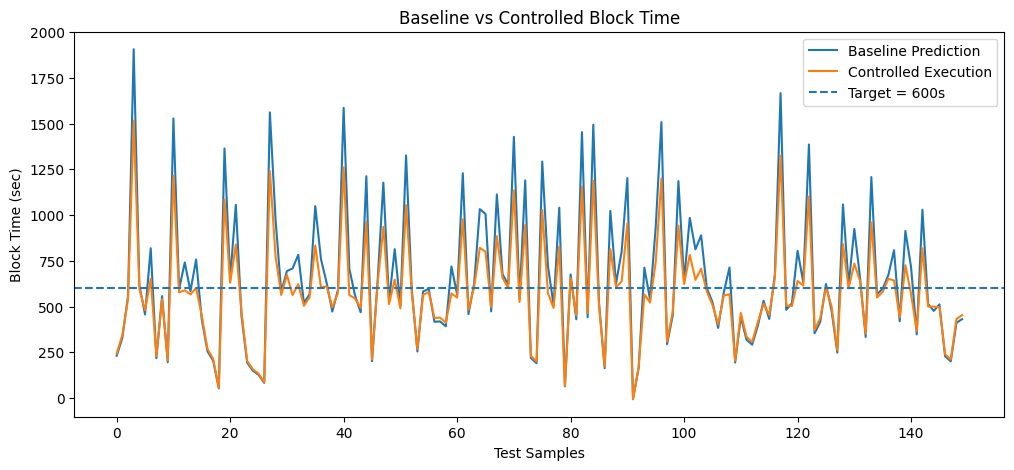

In [ ]:
# =========================================
# 11) PLOT
# =========================================
n = 150

plt.figure(figsize=(12, 5))
plt.plot(eval_df["pred_block_time"].values[:n], label="Baseline Prediction")
plt.plot(eval_df["controlled_block_time"].values[:n], label="Controlled Execution")
plt.axhline(target_block_time, linestyle="--", label="Target = 600s")
plt.title("Baseline vs Controlled Block Time")
plt.xlabel("Test Samples")
plt.ylabel("Block Time (sec)")
plt.legend()
plt.show()